# Phân tích doanh số bán hàng ô tô Ford (2023-2025)

## Mục tiêu
- Khám phá bộ dữ liệu doanh số Ford giai đoạn 2023-2025.
- Trực quan hóa xu hướng bán hàng theo thời gian, sản phẩm và khu vực.
- Xây dựng mô hình dự báo doanh thu (xấp xỉ theo sản lượng xe bán).

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Thiết lập style chung cho toàn bộ notebook
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['font.family'] = 'DejaVu Sans'

In [ ]:
# Đọc dữ liệu từ file Excel đã làm sạch
file_path = 'Ford_Sales_2023_2025_cleaned_v2.xlsx'
df = pd.read_excel(file_path, sheet_name='CleanedData')

print('Lưu ý: Bộ dữ liệu không có cột giá bán, vì vậy doanh số được phân tích theo chỉ số xấp xỉ là sản lượng xe bán.')
display(df.head())

Lưu ý: Bộ dữ liệu không có cột giá bán, vì vậy doanh thu được phân tích theo chỉ số xấp xỉ là sản lượng xe bán.


,Năm,Quý,Tháng,STT,Tên KH,Dòng xe,Màu,Khu vực,Số lượng (xe)
0,2023,Q1,1,5,Lê Long,Territory,Xanh,HCM,1
1,2023,Q1,1,16,Hoàng Tuấn,Ranger,Trắng,HCM,2
2,2023,Q1,1,20,Phan Long,Ranger,Xanh,Đà Nẵng,2
3,2023,Q1,1,24,Trần Nam,Explorer,Đỏ,Hà Nội,1
4,2023,Q1,1,27,Lê Quân,Ranger,Đen,Hải Phòng,2


In [17]:
# Khám phá tổng quan dữ liệu
print('Thông tin dữ liệu:')
df.info()

print('\nThống kê mô tả các cột:')
display(df.describe(include='all').transpose())

Thông tin dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 2109 entries, 0 to 2108
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Năm            2109 non-null   int64
 1   Quý            2109 non-null   str  
 2   Tháng          2109 non-null   int64
 3   STT            2109 non-null   int64
 4   Tên KH         2109 non-null   str  
 5   Dòng xe        2109 non-null   str  
 6   Màu            2109 non-null   str  
 7   Khu vực        2109 non-null   str  
 8   Số lượng (xe)  2109 non-null   int64
dtypes: int64(4), str(5)
memory usage: 148.4 KB

Thống kê mô tả các cột:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Năm,2109.0,NaN,NaN,NaN,2024.100047,0.799042,2023.0,2023.0,2024.0,2025.0,2025.0
Quý,2109,4,Q3,531,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tháng,2109.0,NaN,NaN,NaN,6.5211,3.450402,1.0,4.0,7.0,10.0,12.0
STT,2109.0,NaN,NaN,NaN,358.656235,213.224427,1.0,176.0,352.0,529.0,794.0
Tên KH,2109,24,Trần Cường,115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dòng xe,2109,4,Territory,544,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Màu,2109,5,Đen,458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Khu vực,2109,5,Đà Nẵng,441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Số lượng (xe),2109.0,NaN,NaN,NaN,1.985301,0.816848,1.0,1.0,2.0,3.0,3.0


## Biểu đồ 1 - Doanh số theo thời gian (Line Chart)
Tổng số xe bán theo tháng, vẽ nhiều đường tương ứng mỗi năm để so sánh xu hướng doanh thu xấp xỉ.

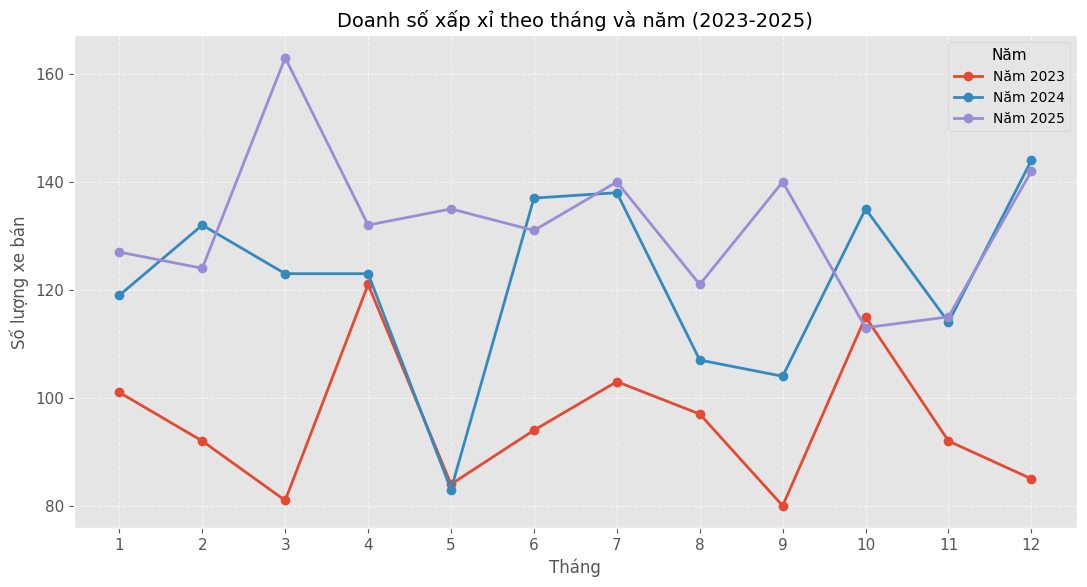

In [18]:
sales_by_year_month = (
    df.groupby(['Năm', 'Tháng'], as_index=False)['Số lượng (xe)']
      .sum()
)

pivot_year_month = sales_by_year_month.pivot(index='Tháng', columns='Năm', values='Số lượng (xe)').sort_index()

fig, ax = plt.subplots()
for year in pivot_year_month.columns:
    ax.plot(pivot_year_month.index, pivot_year_month[year], marker='o', label=f'Năm {year}')

ax.set_title('Doanh số xấp xỉ theo tháng và năm (2023-2025)')
ax.set_xlabel('Tháng')
ax.set_ylabel('Số lượng xe bán')
ax.legend(title='Năm')
ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## Biểu đồ 2 - Doanh số theo năm (Bar Chart)
Tổng hợp doanh thu xấp xỉ theo từng năm và hiển thị nhãn số trên cột.

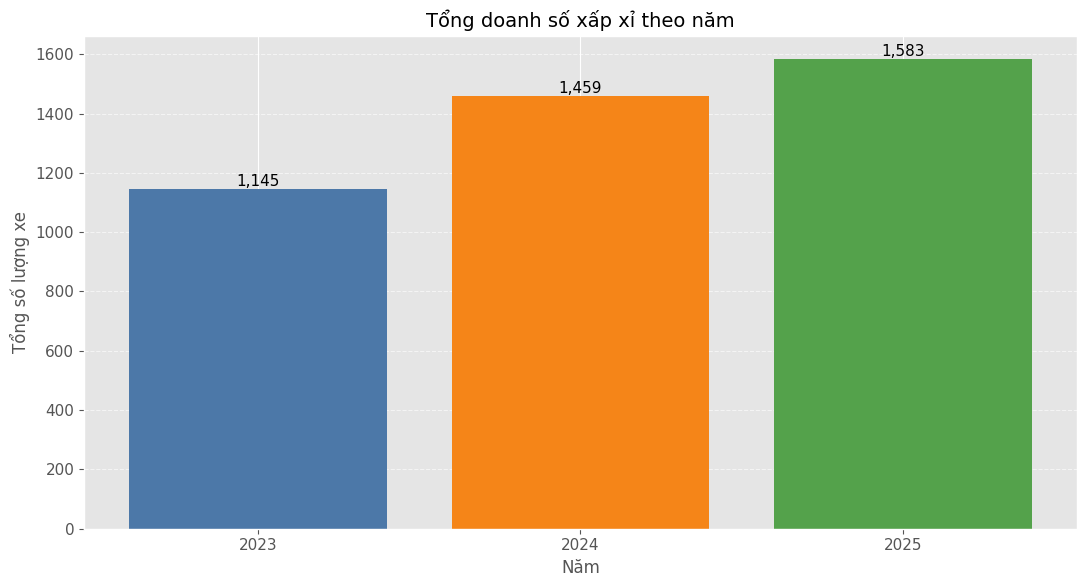

In [19]:
sales_by_year = df.groupby('Năm', as_index=False)['Số lượng (xe)'].sum()

fig, ax = plt.subplots()
bars = ax.bar(sales_by_year['Năm'].astype(str), sales_by_year['Số lượng (xe)'], color=['#4C78A8', '#F58518', '#54A24B'])

ax.set_title('Tổng doanh số xấp xỉ theo năm')
ax.set_xlabel('Năm')
ax.set_ylabel('Tổng số lượng xe')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height):,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Biểu đồ 3 - Doanh số theo quý (Bar Chart)
So sánh tổng doanh thu xấp xỉ giữa các quý Q1-Q4.

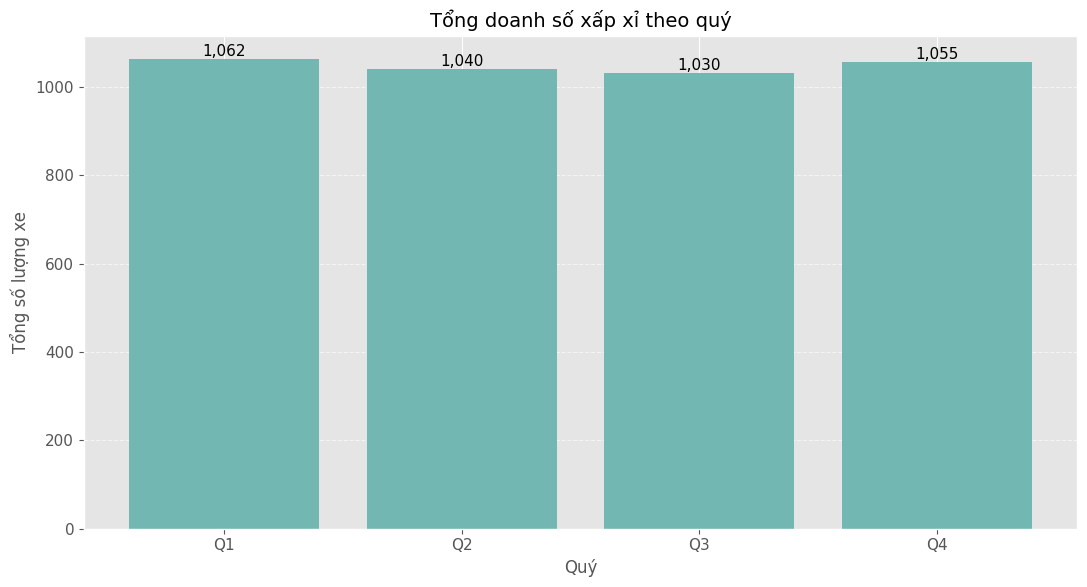

In [20]:
quarter_order = ['Q1', 'Q2', 'Q3', 'Q4']
sales_by_quarter = df.groupby('Quý', as_index=False)['Số lượng (xe)'].sum()
sales_by_quarter['Quý'] = pd.Categorical(sales_by_quarter['Quý'], categories=quarter_order, ordered=True)
sales_by_quarter = sales_by_quarter.sort_values('Quý')

fig, ax = plt.subplots()
bars = ax.bar(sales_by_quarter['Quý'].astype(str), sales_by_quarter['Số lượng (xe)'], color='#72B7B2')

ax.set_title('Tổng doanh số xấp xỉ theo quý')
ax.set_xlabel('Quý')
ax.set_ylabel('Tổng số lượng xe')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height):,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Biểu đồ 4 - Doanh số theo dòng xe (Bar Chart)
Tổng doanh thu xấp xỉ theo từng dòng xe, sắp xếp giảm dần.

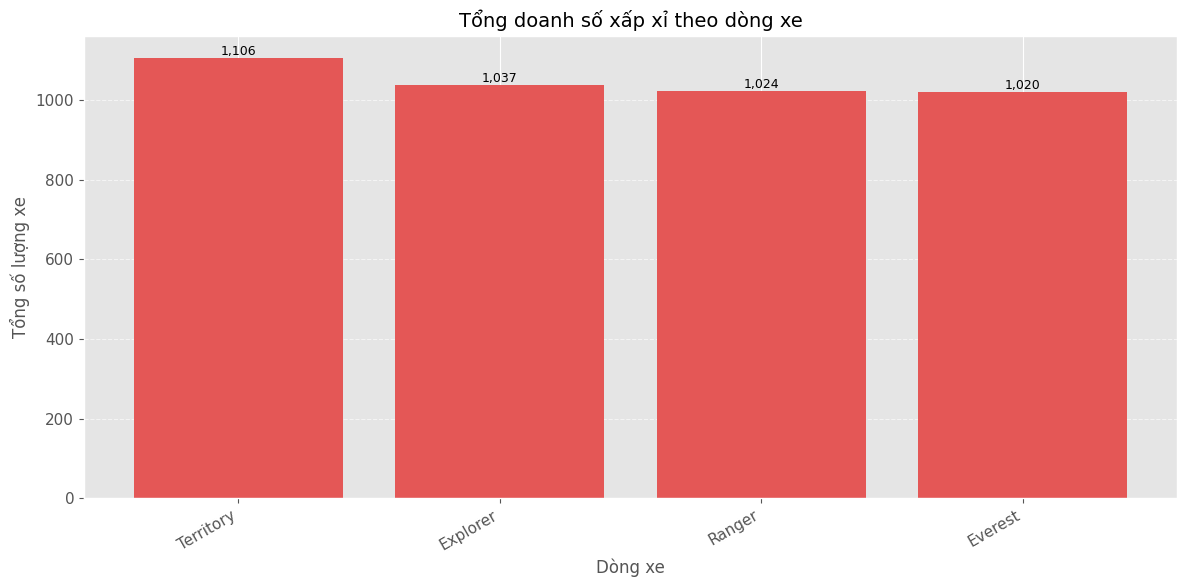

In [21]:
sales_by_model = (
    df.groupby('Dòng xe', as_index=False)['Số lượng (xe)']
      .sum()
      .sort_values('Số lượng (xe)', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(sales_by_model['Dòng xe'], sales_by_model['Số lượng (xe)'], color='#E45756')

ax.set_title('Tổng doanh số xấp xỉ theo dòng xe')
ax.set_xlabel('Dòng xe')
ax.set_ylabel('Tổng số lượng xe')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=30, ha='right')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Biểu đồ 5 - Top 5 dòng xe bán chạy
Xác định 5 dòng xe có doanh thu xấp xỉ cao nhất.

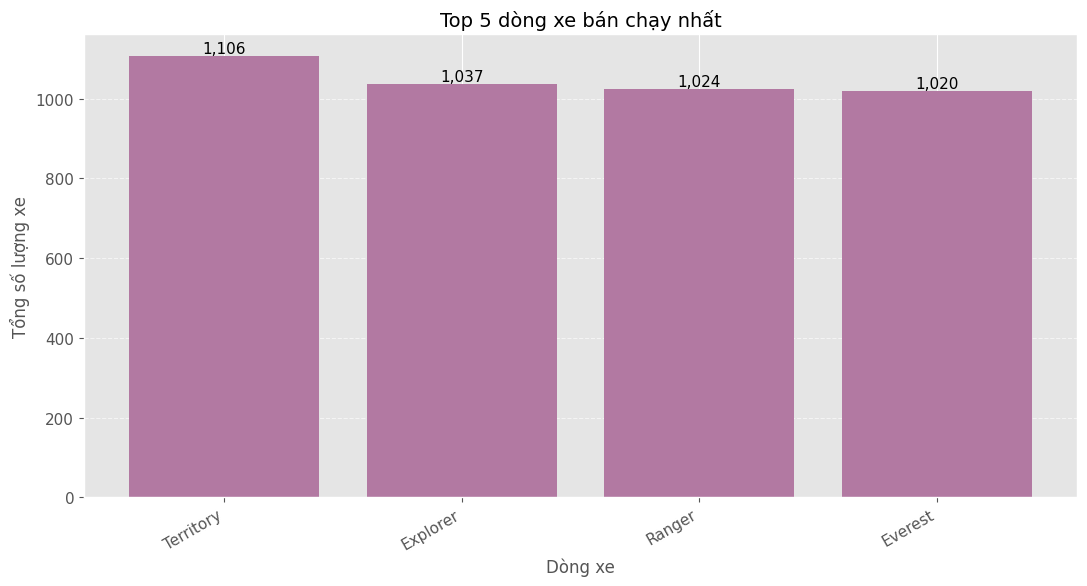

In [22]:
top_5_models = sales_by_model.head(5)

fig, ax = plt.subplots()
bars = ax.bar(top_5_models['Dòng xe'], top_5_models['Số lượng (xe)'], color='#B279A2')

ax.set_title('Top 5 dòng xe bán chạy nhất')
ax.set_xlabel('Dòng xe')
ax.set_ylabel('Tổng số lượng xe')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=30, ha='right')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height):,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Biểu đồ 6 - Doanh số theo khu vực
Đánh giá khu vực có sức mua cao và thấp.

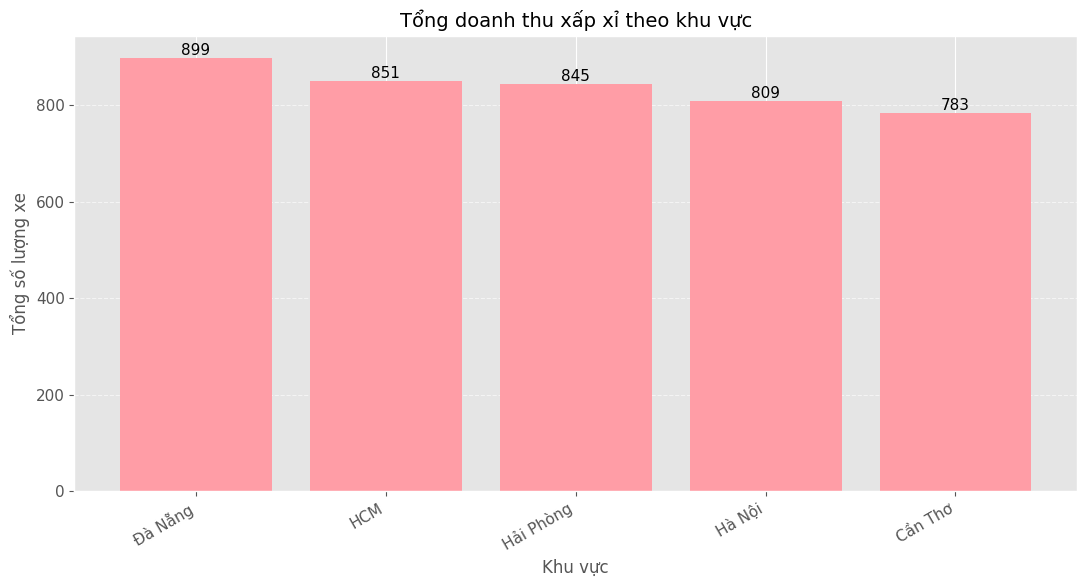

In [23]:
sales_by_region = (
    df.groupby('Khu vực', as_index=False)['Số lượng (xe)']
      .sum()
      .sort_values('Số lượng (xe)', ascending=False)
)

fig, ax = plt.subplots()
bars = ax.bar(sales_by_region['Khu vực'], sales_by_region['Số lượng (xe)'], color='#FF9DA6')

ax.set_title('Tổng doanh thu xấp xỉ theo khu vực')
ax.set_xlabel('Khu vực')
ax.set_ylabel('Tổng số lượng xe')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=30, ha='right')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height):,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Biểu đồ 7 - So sánh khu vực theo năm (Grouped Bar Chart)
So sánh đóng góp doanh số xấp xỉ của mỗi khu vực qua từng năm.

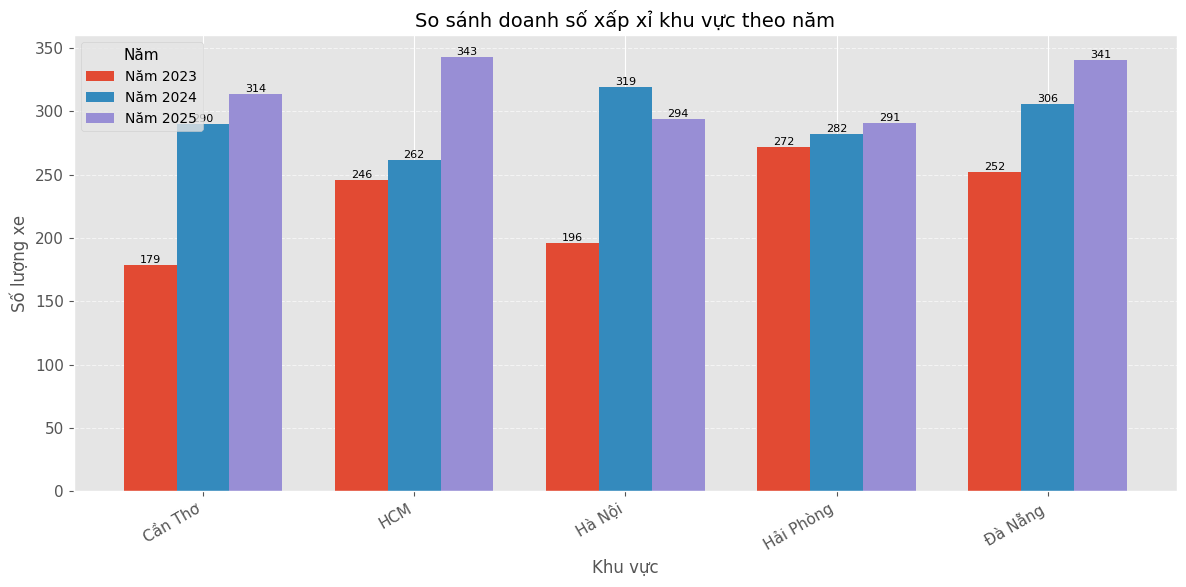

In [24]:
region_year = df.groupby(['Khu vực', 'Năm'], as_index=False)['Số lượng (xe)'].sum()
pivot_region_year = region_year.pivot(index='Khu vực', columns='Năm', values='Số lượng (xe)').fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(pivot_region_year.index))
bar_width = 0.25
years = list(pivot_region_year.columns)

for i, year in enumerate(years):
    positions = [p + i * bar_width for p in x]
    values = pivot_region_year[year].values
    bars = ax.bar(positions, values, width=bar_width, label=f'Năm {year}')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h, f'{int(h):,}', ha='center', va='bottom', fontsize=8)

ax.set_title('So sánh doanh số xấp xỉ khu vực theo năm')
ax.set_xlabel('Khu vực')
ax.set_ylabel('Số lượng xe')
ax.set_xticks([p + bar_width for p in x])
ax.set_xticklabels(pivot_region_year.index, rotation=30, ha='right')
ax.legend(title='Năm')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Biểu đồ 8 - Tỷ trọng dòng xe (Pie Chart)
Tỷ lệ đóng góp doanh thu xấp xỉ của từng dòng xe trong tổng doanh số.

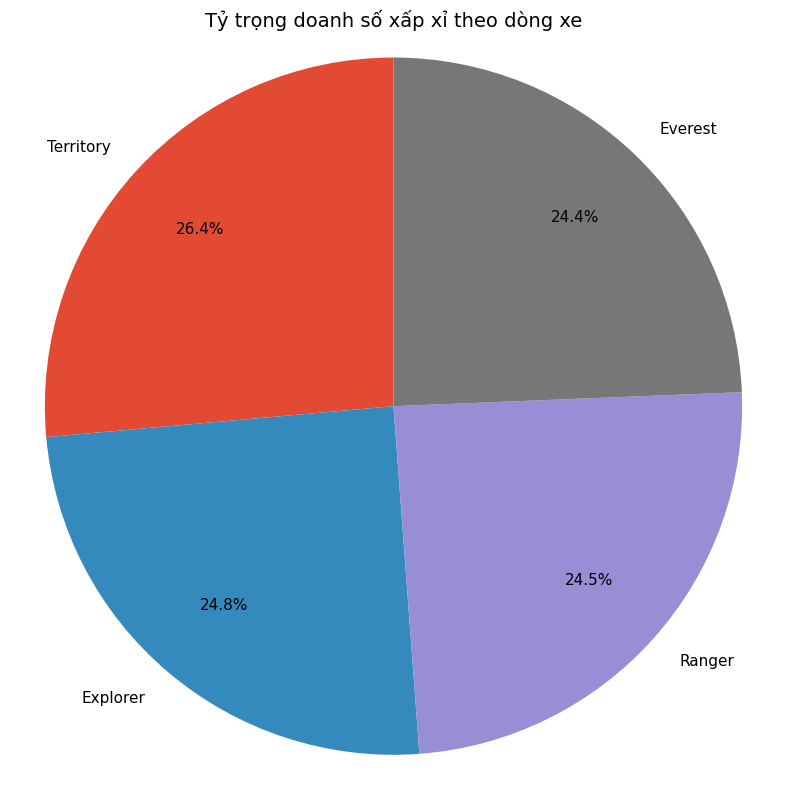

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    sales_by_model['Số lượng (xe)'],
    labels=sales_by_model['Dòng xe'],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75
)

ax.set_title('Tỷ trọng doanh số xấp xỉ theo dòng xe')
ax.axis('equal')
plt.tight_layout()
plt.show()

Biểu đồ 

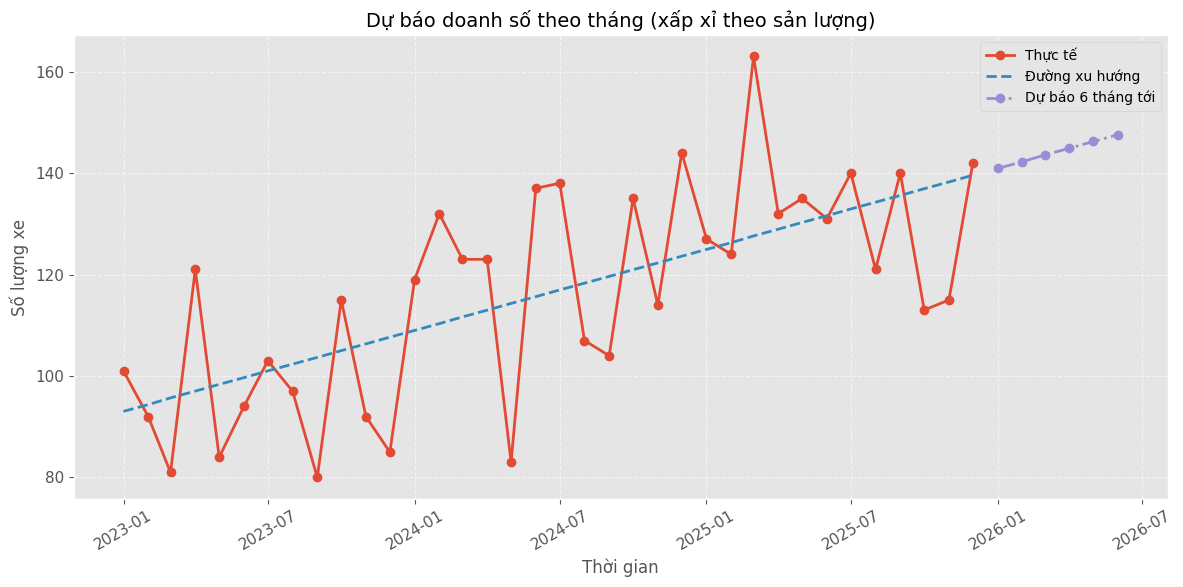

,Tháng dự báo,Doanh số xấp xỉ (số xe)
0,2026-01,141
1,2026-02,142
2,2026-03,144
3,2026-04,145
4,2026-05,146
5,2026-06,148


In [27]:
monthly_sales = (
    df.groupby(['Năm', 'Tháng'], as_index=False)['Số lượng (xe)']
      .sum()
      .sort_values(['Năm', 'Tháng'])
)

monthly_sales['Ngày'] = pd.to_datetime(
    monthly_sales['Năm'].astype(str) + '-' + monthly_sales['Tháng'].astype(str) + '-01' ,
    format='%Y-%m-%d'
 )

x = np.arange(len(monthly_sales))
y = monthly_sales['Số lượng (xe)'].values

# Hồi quy tuyến tính bậc 1 để lấy xu hướng tổng quát
coef = np.polyfit(x, y, 1)
trend_fn = np.poly1d(coef)
y_trend = trend_fn(x)

forecast_horizon = 6
future_x = np.arange(len(monthly_sales), len(monthly_sales) + forecast_horizon)
future_dates = pd.date_range(
    monthly_sales['Ngày'].iloc[-1] + pd.offsets.MonthBegin(1),
    periods=forecast_horizon,
    freq='MS'
 )
future_forecast = np.maximum(0, trend_fn(future_x))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_sales['Ngày'], y, marker='o', label='Thực tế')
ax.plot(monthly_sales['Ngày'], y_trend, linestyle='--', label='Đường xu hướng')
ax.plot(future_dates, future_forecast, marker='o', linestyle='-.', label='Dự báo 6 tháng tới')

ax.set_title('Dự báo doanh số theo tháng (xấp xỉ theo sản lượng)')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Số lượng xe')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

forecast_df = pd.DataFrame({
    'Tháng dự báo': future_dates.strftime('%Y-%m'),
    'Doanh số xấp xỉ (số xe)': np.round(future_forecast, 0).astype(int)
})
display(forecast_df)

## Kết luận
- Sản phẩm bán chạy: Nhóm Top 5 dòng xe cho thấy các mẫu chủ lực đóng góp phần lớn doanh số.
- Khu vực mạnh: Khu vực dẫn đầu doanh số thể hiện thị trường trọng điểm của Ford.
- Xu hướng theo thời gian: Doanh số theo tháng và năm cho thấy các giai đoạn tăng/giảm rõ ràng.
- Dự báo: Mô hình dự báo tuyến tính giúp ước lượng xu hướng doanh thu xấp xỉ cho các tháng tiếp theo.

Notebook được chia theo từng phần độc lập để dễ chạy từng biểu đồ và chụp ảnh đưa vào báo cáo.